In [22]:
txt = """TIETA12 WWW Programming 5-10 ECTS (Language of instruction: English)
HTIS85 Methods in Human-Centered Design 5 ECTS (Language of instruction: English)
Courses independently
TIETA8 Software Engineering 5 ECTS (Language of instruction: English) Continues from the previous period
TIETA18 Student supervision in computer sciences 1-3 ECTS (Language of instruction: English) Continues from the previous period
Period (4-Mar-2019 - 26-May-2019)
General studies
ITIY3 Introduction to Web Publishing - Spring 2019 5 ECTS (Language of instruction: English)"""

In [23]:
import re

re.sub(r"(\d{1,2})-([A-Za-z]{3})-(\d{4})", r"\3-\2-\1", txt)

'TIETA12 WWW Programming 5-10 ECTS (Language of instruction: English)\nHTIS85 Methods in Human-Centered Design 5 ECTS (Language of instruction: English)\nCourses independently\nTIETA8 Software Engineering 5 ECTS (Language of instruction: English) Continues from the previous period\nTIETA18 Student supervision in computer sciences 1-3 ECTS (Language of instruction: English) Continues from the previous period\nPeriod (2019-Mar-4 - 2019-May-26)\nGeneral studies\nITIY3 Introduction to Web Publishing - Spring 2019 5 ECTS (Language of instruction: English)'

In [24]:
import re

re.findall(r"(\d{1,2})-([A-Za-z]{3})-(\d{4})",  txt)

[('4', 'Mar', '2019'), ('26', 'May', '2019')]

In [25]:
import re

def repFunc(m):
    months = {"Mar": "03"}
    return f"{m.group(3)}-{months.get(m.group(2), "NA")}-{m.group(1):>02}"

re.sub(r"(\d{1,2})-([A-Za-z]{3})-(\d{4})", repFunc, txt)

'TIETA12 WWW Programming 5-10 ECTS (Language of instruction: English)\nHTIS85 Methods in Human-Centered Design 5 ECTS (Language of instruction: English)\nCourses independently\nTIETA8 Software Engineering 5 ECTS (Language of instruction: English) Continues from the previous period\nTIETA18 Student supervision in computer sciences 1-3 ECTS (Language of instruction: English) Continues from the previous period\nPeriod (2019-03-04 - 2019-NA-26)\nGeneral studies\nITIY3 Introduction to Web Publishing - Spring 2019 5 ECTS (Language of instruction: English)'

In [26]:
import urllib.request
import xml.etree.ElementTree as ET

url = "https://api.worldbank.org/v2/country/fin;swe/indicator/SP.POP.TOTL;NY.GDP.MKTP.CD?source=2&date=2000:2025&per_page=100"

res = urllib.request.urlopen(url)
xml = ET.fromstring(res.read())

In [27]:
ns = {"wb": "http://www.worldbank.org"}

for el in xml.iterfind("wb:data/wb:indicator[@id='NY.GDP.MKTP.CD']/../wb:value", namespaces=ns):
    print(el.tag, el.text)

{http://www.worldbank.org}value 295532341254.907
{http://www.worldbank.org}value 280241515774.32
{http://www.worldbank.org}value 294223210496.119
{http://www.worldbank.org}value 270000311606.226
{http://www.worldbank.org}value 267014821129.411
{http://www.worldbank.org}value 273869255596.078
{http://www.worldbank.org}value 253846138440
{http://www.worldbank.org}value 238777818792.608
{http://www.worldbank.org}value 233210733506.25
{http://www.worldbank.org}value 273478528954.901
{http://www.worldbank.org}value 270268036626.275
{http://www.worldbank.org}value 257443384492.969
{http://www.worldbank.org}value 275126915515.565
{http://www.worldbank.org}value 249429613683.334
{http://www.worldbank.org}value 253480783439.453
{http://www.worldbank.org}value 285698662071.094
{http://www.worldbank.org}value 256360251537.648
{http://www.worldbank.org}value 217044068234.117
{http://www.worldbank.org}value 204859368790.661
{http://www.worldbank.org}value 197458297639.769
{http://www.worldbank.org}

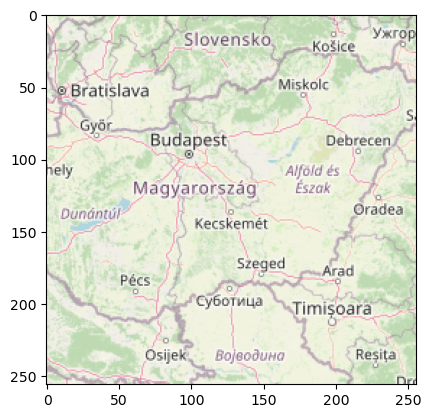

In [28]:
import matplotlib.pyplot as plt
from urllib.request import urlopen, Request
from io import BytesIO

imgbytes = urlopen(Request("https://tile.openstreetmap.org/6/35/22.png",
                           headers={"User-Agent": "DATA.100 v1.0"})).read()
img = plt.imread(BytesIO(imgbytes))
plt.grid(False)
plt.imshow(img)

In [29]:
type(img)

numpy.ndarray

In [30]:
img.shape

(256, 256, 4)

In [31]:
img[0,0]

array([0.9490196, 0.9607843, 0.8980392, 1.       ], dtype=float32)

Alla tapahtui erehdys: vaikka RGB-värikomponenttien arvojen skaala (yleensä) onkin kokonaislukualue 0-255, on matplotlibin yhteydessä käytössä edellisen solun tulosteenkin perusteella liukulukualue 0.0-1.0. Eli kukin välin 0-255 arvo on jaettu 255:llä. Alla oleva operaatio, joka yrittää asettaa pikseleiden arvoiksi ``[255, 255, 255, 1]``, tulostaa tämän vuoksi varoituksen rajan 1.0 ylittämisestä. Lopputulos näytti kuitenkin halutulta, koska matplotlib automaattisesti typisti ylisuuret arvot 255 suurimmaksi sen sallimaksi arvoksi 1.0. Oikea tapa olisi ollut ``testimg[:25, :25] = [1, 1, 1, 1]``.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13725491..255.0].


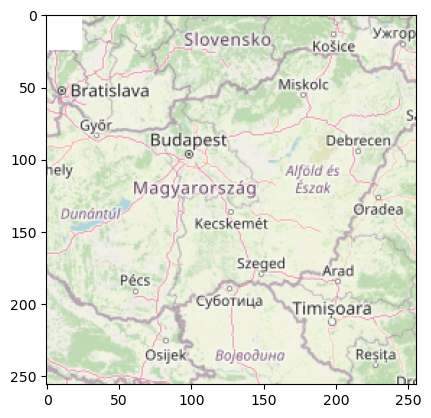

In [32]:
testimg = img.copy()
testimg[:25, :25] = [255, 255, 255, 1]
plt.grid(False)
plt.imshow(testimg)

In [33]:
from urllib.request import urlopen, Request
from io import BytesIO
import time

headers={"User-Agent": "DATA.100 v1.0"}
imgs = []
for x in range(2, 5):
  for y in range(5, 7):
    url = f"https://tile.openstreetmap.org/4/{x}/{y}.png"
    imgbytes = urlopen(Request(url, headers=headers)).read()
    imgs.append(plt.imread(BytesIO(imgbytes)))
    time.sleep(0.5)

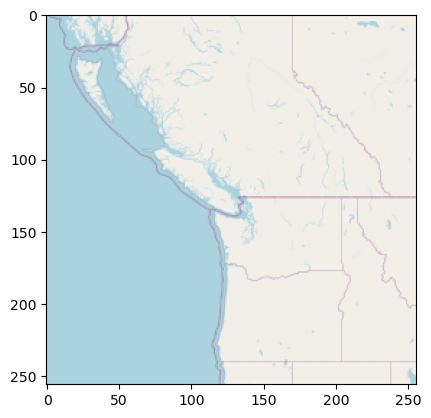

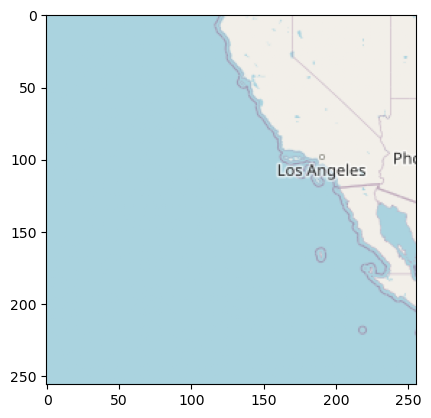

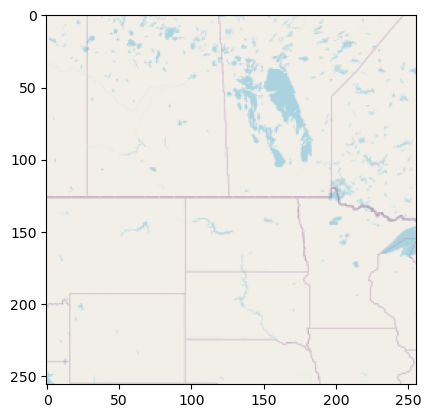

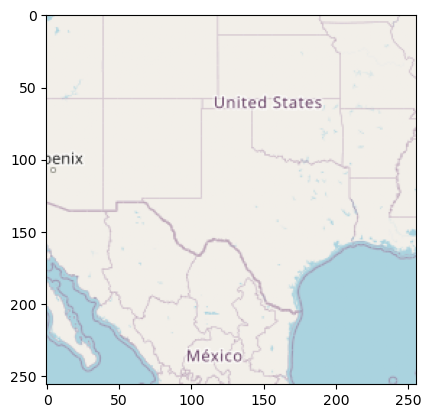

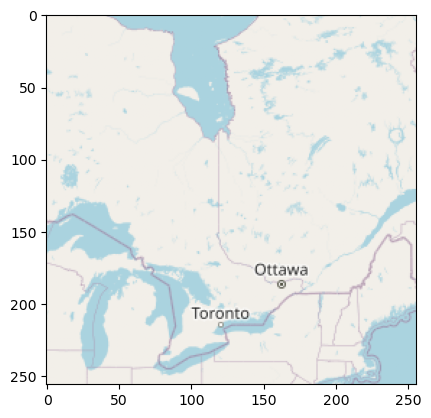

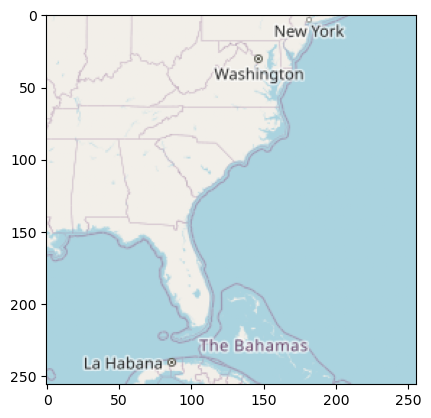

In [34]:
for img in imgs:
  plt.imshow(img)
  plt.grid(False)
  plt.show()

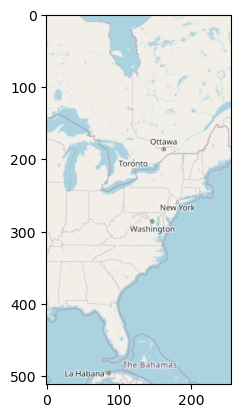

In [35]:
import numpy as np
bigimg = np.vstack(imgs[4:6])
plt.imshow(bigimg)
plt.show()

In [36]:
usa = np.hstack([np.vstack(imgs[i:i+2]) for i in range(0, len(imgs), 2)])
print(usa.shape)

(512, 768, 4)


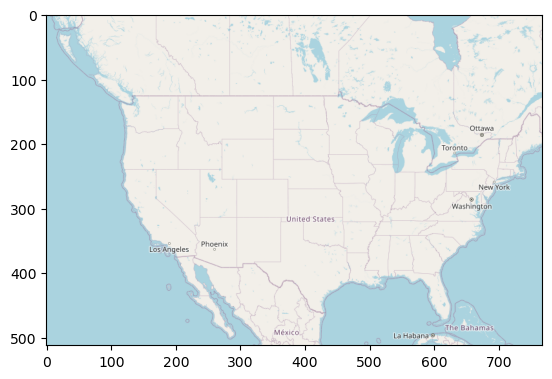

In [37]:
plt.imshow(usa)
plt.grid(False)
plt.show()

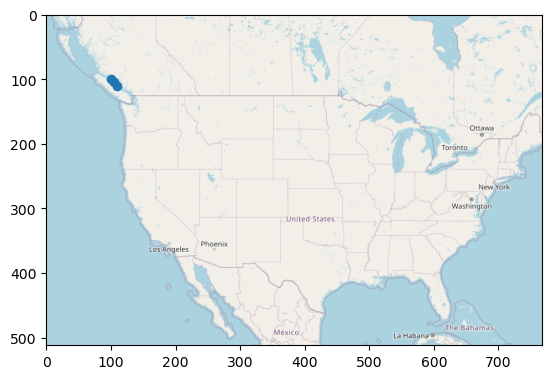

In [38]:
plt.imshow(usa)
plt.grid(False)
plt.scatter([100, 105, 110],[100, 105, 110])
plt.xlim(0, usa.shape[1])
plt.ylim(usa.shape[0], 0)
plt.show()

In [39]:
import json
with open("data/us-states.json") as f:
  stateJson = json.load(f)

stateBounds = {}
for state in stateJson["features"]:
  name = state["properties"]["name"]
  coords = state["geometry"]["coordinates"][0]
  stateBounds[name] = coords
stateBounds

{'Alabama': [[-87.359296, 35.00118],
  [-85.606675, 34.984749],
  [-85.431413, 34.124869],
  [-85.184951, 32.859696],
  [-85.069935, 32.580372],
  [-84.960397, 32.421541],
  [-85.004212, 32.322956],
  [-84.889196, 32.262709],
  [-85.058981, 32.13674],
  [-85.053504, 32.01077],
  [-85.141136, 31.840985],
  [-85.042551, 31.539753],
  [-85.113751, 31.27686],
  [-85.004212, 31.003013],
  [-85.497137, 30.997536],
  [-87.600282, 30.997536],
  [-87.633143, 30.86609],
  [-87.408589, 30.674397],
  [-87.446927, 30.510088],
  [-87.37025, 30.427934],
  [-87.518128, 30.280057],
  [-87.655051, 30.247195],
  [-87.90699, 30.411504],
  [-87.934375, 30.657966],
  [-88.011052, 30.685351],
  [-88.10416, 30.499135],
  [-88.137022, 30.318396],
  [-88.394438, 30.367688],
  [-88.471115, 31.895754],
  [-88.241084, 33.796253],
  [-88.098683, 34.891641],
  [-88.202745, 34.995703],
  [-87.359296, 35.00118]],
 'Alaska': [[[-131.602021, 55.117982],
   [-131.569159, 55.28229],
   [-131.355558, 55.183705],
   [-131.3

Sivulta [https://wiki.openstreetmap.org/wiki/Slippy_map_tilenames](https://wiki.openstreetmap.org/wiki/Slippy_map_tilenames) kopioitu funktio deg2num ottaa parametrikseen
karttakoordinaatit (latitudin ja longitudin) sekä OpenStreetMapin karttatiilen zoom-asteen ja palauttaa karttakoordinaatteja vastaavan sijainnin karttatiilikoordinaateilla ilmaistuna. Tässä esitettyä koodia on muokattu palauttamaan karttatiilikoordinaatit liukulukuina, joiden avulla voidaan laskea tarkka sijainti karttatiilen sisällä. Linkitetyllä sivulla julkaistu alkuperäinen koodi palautti karttatiilikoordinaatit kokonaisluvuiksi typistettyinä, joka kadottaa tiedon tarkemmasta sijannista (kertoo vain sen, mitkä koordinaatit omaavan karttatiilen alueelle sijainti osuu).

In [40]:
import math
def deg2num(lat_deg, lon_deg, zoom):
  lat_rad = math.radians(lat_deg)
  n = 2.0 ** zoom
  xtile = (lon_deg + 180.0) / 360.0 * n
  ytile = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n
  return (xtile, ytile)

Alla kukin osavaltiorajadatan sisältämä karttakoordinaatti muuunnetaan karttatiilikoordinaatiksi funktiolla deg2num. Huomaa, että osavaltiorajadata luettelee koordinaatit muodossa \[longitudi, latitudi\] kun taas deg2num ottaa parametrit järjestyksessä latitudi, longitudi ja zoom-aste.

Muunnoksessa käytetään Pythonin map-funktiota, joka on syntaktisesti hyvin samantapainen kuin esim. filter-funktio. Kutsu map(funktio, iteroitava) käy kaikki jälkimmäisen parametrin iteroitava listaamat arvot läpi ja muuntaa kunkin arvon kutsulla funktio(arvo). Siinä missä filter-funktio palauttaa filter-olion, joka luettelee karsintakriteerin täyttävät arvot, map-funktio palauttaa map-olion, joka luettelee muunnoksen tuottamat arvot. Tämän vuoksi map-kutsu on sisällytetty list-kutsuun, jotta tuloksena olisi konkreettinen muunnetut arvot sisältävä lista.

Esimerkiksi jos on lista ``arvot = [1, 2, 3, 4]``, palauttaa kutsu ``list(map(lambda a: 2*a, arvot))`` listan ``[2, 4, 6, 8]``.

Alla muunnoksen suorittaa lambda-funktio ``lambda lonlat: deg2num(lonlat[1], lonlat[0], 4)``, joten lopputuloksena on lista, jossa kutakin karttakoordinaattiparia ``lonlat`` kohden on kutsun ``deg2num(lonlat[1], lonlat[0], 4)`` palauttama karttatiilikoordinaattipari.

In [41]:
stateTileCoords = {}
for state in ["Alabama", "California"]:
  stateTileCoords[state] = list(map(lambda lonlat: deg2num(lonlat[1], lonlat[0], 4), stateBounds[state]))
stateTileCoords

{'Alabama': [(4.117364622222222, 6.337501277595472),
  (4.195258888888889, 6.338392691953826),
  (4.203048311111111, 6.3847966875365625),
  (4.214002177777778, 6.452224433873255),
  (4.219114, 6.466980288284172),
  (4.223982355555555, 6.4753503455853485),
  (4.222035022222222, 6.48053815297421),
  (4.227146844444444, 6.483705731165269),
  (4.219600844444444, 6.490321959605433),
  (4.219844266666667, 6.496929108892656),
  (4.215949511111111, 6.5058200151010634),
  (4.220331066666667, 6.521554090908494),
  (4.217166622222223, 6.535244178773839),
  (4.222035022222222, 6.549464181746434),
  (4.200127244444444, 6.549748167058196),
  (4.106654133333333, 6.549748167058196),
  (4.105193644444444, 6.5565588284613145),
  (4.115173822222222, 6.56647437868398),
  (4.113469911111111, 6.574957805337406),
  (4.116877777777778, 6.579194113974956),
  (4.110305422222222, 6.586810482195775),
  (4.104219955555555, 6.588501470805793),
  (4.093022666666667, 6.580040906055849),
  (4.091805555555555, 6.567323

Nyt kun tiedetään karttatiilikoordinaatit, voidaan laskea niitä vastaavat pikselikoordinaatit aiemmin luodun karttakuvan puitteissa.

Laskentakaava on varsin yksinkertainen kunhan vain tiedämme kunkin karttatiilen koon pikseleinä. Tässä tapauksessa tiedämme, että kukin karttatiili kattaa 256x256 pikseliä. Siten yksi karttatiiliyksikkö vastaa 256 pikseliä. On kuitenkin luonnollisesti huomioitava, että karttakuvamme kattaa vain osan koko maapallon kattavasta karttatiilipeitteestä. Tämän vuoksi alla kustakin karttatiilikoordinaatista vähennetään ensin pois niiden karttatiilien osuus, joita karttakuva ei sisällä. Karttakuvan nollapisteenä toimii sen vasen yläkulma, jonka tiilikoordinaatit ovat 2 ja 5. Nämä arvot on asetettu alla muuttujiin baseX ja baseY. Tämän jälkeen kukin x-koordinaatti xy\[0\] muunnetaan pikselikoordinaatiksi kaavalla (xy\[0\] - baseX)*256, ja y-koordinaattien kohdalla toimitaan vastaavalla tavalla. Muunnokset tehdään jälleen map-funktiolla. 

In [42]:
baseX = 2
baseY = 5
tileSize = 256

def mapToPix(xy):
  return ((xy[0]-baseX)*256, (xy[1]-baseY)*256)

statePixCoords = {}
for state in stateTileCoords:
  statePixCoords[state] = list(map(mapToPix, stateTileCoords[state]))
statePixCoords

{'Alabama': [(542.045343288889, 342.40032706444094),
  (561.9862755555555, 342.62852914017935),
  (563.9803676444444, 354.50795200936),
  (566.7845575111112, 371.76945507155324),
  (568.0931840000001, 375.54695380074804),
  (569.3394830222221, 377.6896884698492),
  (568.8409656888889, 379.01776716139784),
  (570.1495921777778, 379.82866717830893),
  (568.2178161777776, 381.5224216589909),
  (568.2801322666667, 383.21385187652004),
  (567.2830748444444, 385.48992386587224),
  (568.4047530666667, 389.5178472725745),
  (567.594655288889, 393.02250976610276),
  (568.8409656888889, 396.6628305270872),
  (563.2325745777778, 396.73553076689814),
  (539.3034581333332, 396.73553076689814),
  (538.9295729777778, 398.4790600860965),
  (541.4844984888889, 401.0174409430988),
  (541.0482972444445, 403.18919816637595),
  (541.9207111111111, 404.2736931775887),
  (540.2381880888888, 406.2234834421183),
  (538.6803086222221, 406.6563765262831),
  (535.8138026666668, 404.49047195029743),
  (535.5022222

Kun pikselikoordinaatit on laskettu, on niiden kuvaamien osavaltiorajojen piirtäminen kartalle varsin yksinkertaista hyödyntäen [matplotlibin Polygon-tyyppiä](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Polygon.html#matplotlib.patches.Polygon). Polygon-tyyppi määrittää suorakulmion listaamalla suorakulmion kulmien koordinaatit. Tämä vastaa tapaa, jolla osavaltioiden rajat on kuvattu. Voimme siis yksinkertaisesti luoda Polygon-olion, jonka määrittämän monikulmion pisteiksi annetaan osavaltion rajan kuvaavat pikselikoordinaatit. Monikulmiolle voi lisäksi määrittää esim. täytön ja reunaviivojen värit.

Polygon-olion kuvaaman monikulmion voi piirtää muotoa ``ax.add_patch(polygon_olio)`` olevalla kutsulla. Tässä ax on viittaus tämänhetkisen matplotlib-kuvan "akseleihin", ja sellaisen voi pyytää matplotlib-kirjaston kutsulla ``plt.gca()``.

Kun matplotlibillä piirtää kuvaajaan, sillä on usein tapana antaa kuvan akseleille hieman väljyyttä (esim. y-akseli voi kattaa hieman laajemman intervallin mitä tarvittaisiin datan arvojen esittämiseen). Alla funktioiden ``plt.xlim`` ja ``plt.ylim`` avulla lopuksi vielä rajataan sekä x- että y-akseliet kattamaan vain kuvan koko: x-akselin koordinaattiväli on ``0...usa.shape[1]`` ja y-akselin ``usa.shape[0]...0``. Jälkimmäinen antaa arvorajat käänteisessä järjestyksessä, koska kuvassa y-akselin arvot kasvavat ylhäältä alas eivätkä tavalliseen tapaan alhaalta ylös.

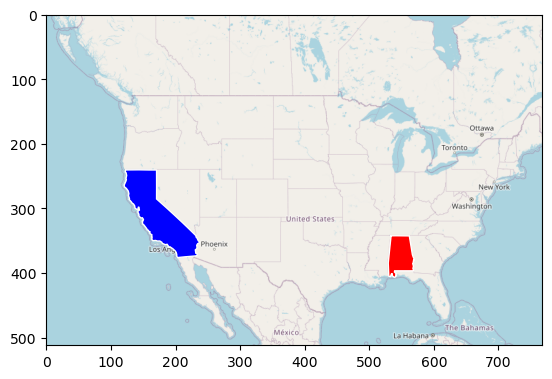

In [43]:
from matplotlib.patches import Polygon

colors = {"Alabama": "red", "California": "blue"}
plt.imshow(usa)
plt.grid(False)
ax = plt.gca()
for state in statePixCoords:
  ax.add_patch(Polygon(statePixCoords[state], facecolor=colors[state], edgecolor="white"))
plt.xlim(0, usa.shape[1])
plt.ylim(usa.shape[0], 0)
plt.show()